# Projeto 1 — Notebook 01 · Auditoria da base e decisão do rótulo

**Do texto à decisão: sentimento e temas nas avaliações da Americanas**
Projeto Integrado: Redes Sociais e Marketing · CDIA · PUC-SP · 2026.2

| # | Nome completo | RA |
|---|---|---|
| 1 | Matheus Campos Amorim | 00361482 |
| 2 | Filipe Kobrem dos Santos | 00364821 |
| 3 | Rafael Fassini Menoce  | 00363966 |
| 4 | Gabriel Moraes | 00127580 |
| 5 | Qingna Zhan | 00360083 |

**Base:** B2W-Reviews01 — 132.373 avaliações da Americanas.com (01/01 a 31/05/2018), baixada do
**repositório oficial** [github.com/americanas-tech/b2w-reviews01](https://github.com/americanas-tech/b2w-reviews01)
pela URL *raw*. Nenhuma cópia (Kaggle, Hugging Face) foi usada.

**Licença:** CC BY-NC-SA 4.0 — uso não comercial, com atribuição.
REAL, L.; OSHIRO, M.; MAFRA, A. *B2W-Reviews01: an open product reviews corpus*. STIL — Symposium in
Information and Human Language Technology, 2019.

**Ordem de execução:** `01_auditoria` → `02_sentimento` → `03_temas`. Este notebook grava
`artefatos/base_auditada.parquet` e `artefatos/decisoes.json`, que os outros dois leem.

**Convenção de citação:** toda célula de código começa com `⟦célula 01.NN⟧`. O relatório cita
cada número pela célula que o produziu.

---

## O que este notebook responde, antes de qualquer modelo

1. Quantos textos distintos a base tem, de verdade? Quantas avaliações repetem texto de outra?
2. Quem gerou o rótulo, e como? A nota e a recomendação concordam? Onde discordam?
3. O que está escrito dentro do texto que já entrega o rótulo? (começando pelo título)
4. Qual é a proporção das classes — e quanto acerta quem chuta sempre a maioria?

E, no fim, a **decisão do rótulo**, justificada com número.

In [1]:
# ⟦célula 01.01⟧
import importlib.util, subprocess, sys
for pacote in ["pyarrow"]:
    if importlib.util.find_spec(pacote) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pacote])

import json, re, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, recall_score

SEMENTE = 42
for pasta in ["dados", "artefatos", "figuras"]:
    Path(pasta).mkdir(exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
AZUL, LARANJA, CINZA, VERDE = "#2E5E8C", "#C0592B", "#9A9A9A", "#4C8C4A"
pd.set_option("display.max_colwidth", 140)

def salvar(fig, nome):
    fig.savefig(f"figuras/{nome}.png", bbox_inches="tight", dpi=150)
    return f"figuras/{nome}.png"

print("pandas", pd.__version__, "· numpy", np.__version__)

pandas 3.0.6 · numpy 2.5.3


## 0. Coleta — baixar do repositório oficial

O arquivo é baixado uma vez para `dados/` e reaproveitado nas execuções seguintes. A pasta
`dados/` **não vai no zip da entrega**.

In [2]:
# ⟦célula 01.02⟧
URL = "https://raw.githubusercontent.com/americanas-tech/b2w-reviews01/main/B2W-Reviews01.csv"
ARQUIVO = Path("dados/B2W-Reviews01.csv")
if not ARQUIVO.exists():
    urllib.request.urlretrieve(URL, ARQUIVO)

df = pd.read_csv(ARQUIVO, low_memory=False)
print(f"{len(df):,} linhas × {df.shape[1]} colunas · arquivo de {ARQUIVO.stat().st_size/1e6:.1f} MB".replace(",", "."))
print(f"período: {df['submission_date'].min()} → {df['submission_date'].max()}")
print(f"avaliadores distintos: {df['reviewer_id'].nunique():,} · produtos: {df['product_id'].nunique():,} · "
      f"categorias nível 1: {df['site_category_lv1'].nunique()}".replace(",", "."))

132.373 linhas × 14 colunas · arquivo de 49.5 MB
período: 2018-01-01 00:11:28 → 2018-05-31 23:50:33
avaliadores distintos: 112.993 · produtos: 48.001 · categorias nível 1: 54


Uma amostra só com as colunas de **conteúdo**. As colunas de perfil (ano de nascimento, gênero,
estado) ficam de fora de qualquer exibição linha a linha: elas só entram em análise agregada
(regra de dados pessoais do enunciado).

In [3]:
# ⟦célula 01.03⟧
CONTEUDO = ["site_category_lv1", "review_title", "overall_rating", "recommend_to_a_friend", "review_text"]
df[CONTEUDO].sample(6, random_state=SEMENTE)

,site_category_lv1,review_title,overall_rating,recommend_to_a_friend,review_text
328,Alimentos e Bebidas,Produto de excelente qualidade.,5,Yes,"Ele e muito bom ,bom, bom , bom , bom. BOM BOM BOM Tao bom ,que fica ruim."
83773,Saúde,bom produto,4,Yes,cumpre a funcao desejada melhor que a marca concorrente
117905,Relógios,Produto pessimo,1,No,Não tem luz então não funciona a noite. Sem manual não acerta de jeito nenhum. O meu veio com o pé quebrado e devolveram o dinheiro
47675,Móveis,Perfeito,4,Yes,"Lindo painel,material de qualidade,forte e resistente...adoreiiiii."
51037,Câmeras e Filmadoras,Excelente lente foco fantático,5,Yes,Muito boa a lente estabilização e foco maravilhoso
42872,Esporte e Lazer,vocês não entregam e querem que avalie,1,No,"p já falei que vocês não entregaram a mercadoria Que bo.ta de empresa é essa , desorganizada, é a segunda vez que..."


## 1. Faltantes por coluna — e o que fazemos com cada um

In [4]:
# ⟦célula 01.04⟧
faltantes = pd.DataFrame({"faltantes": df.isna().sum(), "% da base": (df.isna().mean() * 100).round(2)})
faltantes = faltantes[faltantes["faltantes"] > 0].sort_values("faltantes", ascending=False)
faltantes

,faltantes,% da base
product_brand,91391,69.04
reviewer_birth_year,5984,4.52
reviewer_gender,4136,3.12
site_category_lv2,4013,3.03
reviewer_state,3991,3.01
review_text,3275,2.47
review_title,302,0.23
product_name,84,0.06
recommend_to_a_friend,18,0.01
site_category_lv1,6,0.00


**Decisão por coluna** (números da ⟦célula 01.04⟧):

| coluna | faltantes | decisão | por quê |
|---|---|---|---|
| `product_brand` | 91.391 (69,0%) | **não usar** | falta em dois terços da base; usá-la criaria um recorte só com quem tem marca |
| `reviewer_birth_year` · `gender` · `state` | 3,0% a 4,5% | **não entram no modelo**; ficam só para tabela agregada | são perfil, não texto; regra de dados pessoais do enunciado |
| `site_category_lv2` | 4.013 (3,0%) | não usar | o recorte do notebook 03 é pelo nível 1 |
| `review_text` | 3.275 (2,5%) | **remover** do modelo e dos temas | não há o que classificar; o título sozinho não é o texto (ver Pergunta 3) |
| `review_title` | 302 (0,2%) | preencher com `""` | só é usado no teste de vazamento |
| `product_name` | 84 | manter | só para leitura de exemplos |
| `recommend_to_a_friend` | 18 | manter como está | só é usada para auditar o rótulo, nunca como entrada |
| `site_category_lv1` | 6 | manter | ficam fora dos recortes por categoria |

---
## 2. Pergunta 1 — Quantos textos distintos a base tem, de verdade?

In [5]:
# ⟦célula 01.05⟧
texto = df["review_text"]
com_texto = texto.notna()
n_com_texto = int(com_texto.sum())
n_distintos = texto.nunique()
repetem = int(texto[com_texto].duplicated().sum())
textos_repetidos = texto[com_texto].value_counts()
textos_repetidos = textos_repetidos[textos_repetidos > 1]

print(f"avaliações sem texto:                         {(~com_texto).sum():>7,}".replace(",", "."))
print(f"avaliações com texto:                         {n_com_texto:>7,}".replace(",", "."))
print(f"textos distintos:                             {n_distintos:>7,}".replace(",", "."))
print(f"   (contando o 'vazio' como um texto:         {texto.nunique(dropna=False):>7,})".replace(",", "."))
print(f"avaliações que repetem texto de outra:        {repetem:>7,}  ({repetem/n_com_texto:.1%} das com texto)".replace(",", "."))
print(f"textos que aparecem mais de uma vez:          {len(textos_repetidos):>7,}".replace(",", "."))

avaliações sem texto:                           3.275
avaliações com texto:                         129.098
textos distintos:                             126.724
   (contando o 'vazio' como um texto:         126.725)
avaliações que repetem texto de outra:          2.374  (1.8% das com texto)
textos que aparecem mais de uma vez:            1.735


In [6]:
# ⟦célula 01.06⟧
# os textos mais repetidos: quem escreve a mesma frase 50 vezes?
top_rep = textos_repetidos.head(12).rename("vezes").reset_index()
top_rep["notas"] = top_rep["review_text"].map(
    lambda t: " ".join(map(str, sorted(df.loc[texto == t, "overall_rating"].unique()))))
top_rep["produtos distintos"] = top_rep["review_text"].map(lambda t: df.loc[texto == t, "product_id"].nunique())
top_rep

,review_text,vezes,notas,produtos distintos
0,Entrega super rápida . Parabéns pela agilidade na entrega e qualidade no produto .,57,5,57
1,Parabéns pela agilidade na entrega e qualidade no produto .,52,5,52
2,Não compre se for dá Up2games ela rouba seu dinheiro ! É vergonhoso como a americanas tem parceria com esse lixo de loja !,39,1,39
3,Gostei muito do produto . Entrega super rápida . Parabéns pela agilidade na entrega e qualidade no produto .,38,5,38
4,"o produto chegou muito rápido, bem antes do combinado, recomenda a todos, empresa com atendimento ao cliente nota 10",34,5,34
5,"produto chegou super rápido, bem antes do combinado, recomendo a todos, empresa com atendimento vip com o cliente. parabéns",34,5,34
6,NÃO RECOMENDO TAPETE DE PÉSSIMA QUALIDADE BEM DIFERENTE DA FOTO SEM SE COMPARA.,23,1,21
7,"MUITO LEVE E PRATICO FÁCIL DE LEVA, ÓTIMO PRA TRABALHOS DE FACULDADE.",19,4 5,18
8,"Empresa com atendimento ao cliente otima, muito ágil para tirar as dúvidas e mais, o móvel chegou antes da data prevista, recomendo a todos",17,5,17
9,Fornecedora e a Americanas.com não se entendem e o cliente fica sem receber o produto,15,1,15


In [7]:
# ⟦célula 01.07⟧
# as cópias concordam no rótulo? (classe binária: 1-2 negativo, 4-5 positivo; 3 fica fora desta conta)
bin_ = df.loc[com_texto & (df["overall_rating"] != 3), ["review_text", "overall_rating"]].copy()
bin_["pos"] = bin_["overall_rating"] >= 4
por_texto = bin_.groupby("review_text")["pos"].agg(["size", "nunique"])
conflito = por_texto[(por_texto["size"] > 1) & (por_texto["nunique"] > 1)]
print(f"textos repetidos (com nota ≠ 3): {int((por_texto['size'] > 1).sum()):,}".replace(",", "."))
print(f"   desses, com cópias em classes OPOSTAS: {len(conflito)} texto(s), {int(conflito['size'].sum())} linhas")
conflito.sort_values("size", ascending=False).head(5)

textos repetidos (com nota ≠ 3): 1.571
   desses, com cópias em classes OPOSTAS: 1 texto(s), 2 linhas


,size,nunique
review_text,,
Não recebi ainda Não recebi ainda Não recebi ainda,2,2


In [8]:
# ⟦célula 01.08⟧
# título idêntico ao texto: o número depende do que se entende por "idêntico"
titulo = df["review_title"].fillna("")
txt = df["review_text"].fillna("")
def espaco_minuscula(s): return re.sub(r"\s+", " ", s.strip().lower())
def sem_pontuacao(s):    return re.sub(r"[^\w\s]", "", espaco_minuscula(s)).strip()

iguais = pd.Series({
    "exatamente igual": int(((titulo == txt) & (txt != "")).sum()),
    "igual após strip": int(((titulo.str.strip() == txt.str.strip()) & (txt != "")).sum()),
    "igual em minúsculas e espaços normalizados": int(((titulo.map(espaco_minuscula) == txt.map(espaco_minuscula)) & (txt != "")).sum()),
    "igual também sem pontuação": int(((titulo.map(sem_pontuacao) == txt.map(sem_pontuacao)) & (txt != "")).sum()),
}, name="avaliações")
iguais.to_frame()

,avaliações
exatamente igual,315
igual após strip,315
igual em minúsculas e espaços normalizados,320
igual também sem pontuação,466


**Resposta à Pergunta 1.** Das 129.098 avaliações com texto, há **126.724 textos distintos**. São
**2.374 avaliações (1,8%) que repetem o texto de outra**, distribuídas em 1.735 textos que aparecem mais de uma
vez (⟦célula 01.05⟧). O "126.725" do enunciado é o mesmo número com o vazio contado como um texto.

A leitura dos mais repetidos (⟦célula 01.06⟧) diz mais que a contagem:

* **Texto-modelo de 5 estrelas.** *"Parabéns pela agilidade na entrega e qualidade no produto"* aparece 52 vezes,
  e a versão com *"Entrega super rápida"* na frente, 57 vezes. Cada uma está em **57 e 52 produtos diferentes**,
  sempre com nota 5. Não é um cliente empolgado: é um texto padrão, colado por alguém (vendedor parceiro,
  campanha de avaliação ou robô). O mesmo vale para as duas frases "chegou bem antes do combinado" (34 cada).
* **Campanha contra um vendedor.** *"Não compre se for dá Up2games ela rouba seu dinheiro"* aparece **39 vezes, em
  39 produtos**, sempre com nota 1. É um protesto colado em série, e mostra que parte das reclamações é contra o
  **vendedor do marketplace**, não contra a Americanas nem contra o produto.
* **Cópias com rótulos opostos:** 1 texto só (2 linhas), *"Não recebi ainda"* repetido (⟦célula 01.07⟧). O
  problema da duplicata aqui não é ruído de rótulo; é **vazamento entre treino e teste**: uma cópia no treino e
  outra no teste, e o modelo é avaliado num texto que já viu.

**Decisão:** antes do split, removemos as cópias (fica a primeira ocorrência) e o texto conflitante sai
inteiro. É o que o Lab 05 já tinha mostrado nesta base: sem isso, 5,2% dos textos de teste estavam no treino.

**Título idêntico ao texto** (⟦célula 01.08⟧): 315 na comparação exata, 320 ignorando maiúsculas e espaços, 466
ignorando também a pontuação. Não reproduzimos o 388 do enunciado com nenhuma normalização simples. O número
depende do que se chama de "idêntico", e o que importa para o projeto é a ordem de grandeza: algumas centenas de
avaliações em que o título é o próprio texto.

---
## 3. Pergunta 2 — Quem gerou o rótulo, e como? Nota e recomendação concordam?

Os dois rótulos (`overall_rating` e `recommend_to_a_friend`) foram preenchidos **pelo próprio
cliente, no mesmo formulário e no mesmo momento** em que ele escreveu título e texto. Não há anotador
externo, nem regra automática como o `:)` do Lab 05. Isso tem duas consequências: o rótulo é
**autodeclarado** (é a opinião do cliente sobre o próprio texto), e tudo o que o cliente escreveu no
formulário — inclusive o título — foi escrito **sabendo** a nota que ia dar.

In [9]:
# ⟦célula 01.09⟧
rec = df["recommend_to_a_friend"]
cruz = pd.crosstab(df["overall_rating"], rec.fillna("(vazio)"), margins=True, margins_name="total")
cruz_pct = pd.crosstab(df["overall_rating"], rec, normalize="index").mul(100).round(1)
cruz_pct.columns = [f"% {c}" for c in cruz_pct.columns]
display(cruz)
cruz_pct

recommend_to_a_friend,(vazio),No,Yes,total
overall_rating,,,,
1,0,26574,795,27369
2,0,6321,2068,8389
3,2,1879,14434,16315
4,0,508,31837,32345
5,16,705,47234,47955
total,18,35987,96368,132373


,% No,% Yes
overall_rating,,
1,97.1,2.9
2,75.3,24.7
3,11.5,88.5
4,1.6,98.4
5,1.5,98.5


In [10]:
# ⟦célula 01.10⟧
tres = df["overall_rating"] == 3
neg_mas_recomenda = int(((df["overall_rating"] <= 2) & (rec == "Yes")).sum())
pos_mas_nao = int(((df["overall_rating"] >= 4) & (rec == "No")).sum())
pct_3_recomenda = (rec[tres] == "Yes").mean()

# a "regra de uma linha" do Lab 05, agora com a recomendação: Yes -> positivo, No -> negativo
binario = df["overall_rating"] != 3
regra = np.where(rec[binario] == "Yes", "positivo", "negativo")
verdade = np.where(df.loc[binario, "overall_rating"] >= 4, "positivo", "negativo")
acerto_regra = (regra == verdade)[rec[binario].notna().values].mean()

print(f"das avaliações com 3 estrelas, recomendam: {pct_3_recomenda:.1%}")
print(f"1-2 estrelas que RECOMENDAM:     {neg_mas_recomenda:,}".replace(",", "."))
print(f"4-5 estrelas que NÃO recomendam: {pos_mas_nao:,}".replace(",", "."))
print(f"regra 'recomenda → positivo', nas notas 1-2 e 4-5: acerta {acerto_regra:.1%} sem ler uma palavra")

das avaliações com 3 estrelas, recomendam: 88.5%
1-2 estrelas que RECOMENDAM:     2.863
4-5 estrelas que NÃO recomendam: 1.213
regra 'recomenda → positivo', nas notas 1-2 e 4-5: acerta 96.5% sem ler uma palavra


figuras/01_nota_x_recomendacao.png


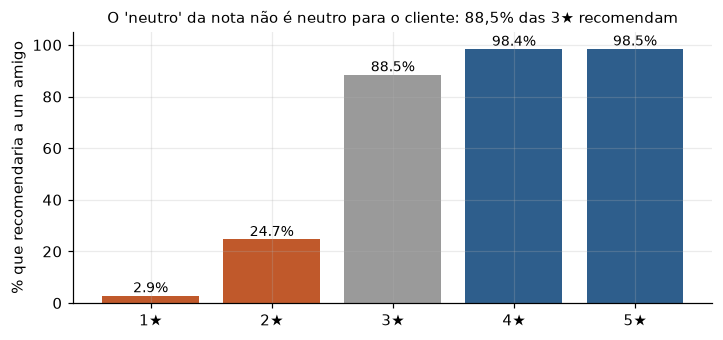

In [11]:
# ⟦célula 01.11⟧
fig, eixo = plt.subplots(figsize=(7.5, 3.2))
pct_sim = cruz_pct["% Yes"]
cores = [LARANJA, LARANJA, CINZA, AZUL, AZUL]
barras = eixo.bar(pct_sim.index.astype(str) + "★", pct_sim.values, color=cores)
eixo.bar_label(barras, fmt="%.1f%%", fontsize=9)
eixo.set_ylabel("% que recomendaria a um amigo")
eixo.set_ylim(0, 105)
eixo.set_title("O 'neutro' da nota não é neutro para o cliente: 88,5% das 3★ recomendam", fontsize=10)
print(salvar(fig, "01_nota_x_recomendacao")); plt.show()

In [12]:
# ⟦célula 01.12⟧
# três avaliações de cada zona de discordância (só conteúdo, sem perfil)
zona_a = df[(df["overall_rating"] <= 2) & (rec == "Yes") & com_texto]
zona_b = df[(df["overall_rating"] >= 4) & (rec == "No") & com_texto]
print("1-2★ que recomendam:")
display(zona_a[CONTEUDO].sample(3, random_state=SEMENTE))
print("4-5★ que não recomendam:")
zona_b[CONTEUDO].sample(3, random_state=SEMENTE)

1-2★ que recomendam:


,site_category_lv1,review_title,overall_rating,recommend_to_a_friend,review_text
131705,Celulares e Smartphones,Bom,2,Yes,Só que ele está com problemas não está aparecendo as fotos e não está fazendo ligação direito como faço para trocar
97880,TV e Home Theater,"Ainda não pude testar,, está nos correios,,",2,Yes,Estou aguardando entrega. Do conversor pra ver se realmente ele é bom. Comprei. Esse aparelho. No dia 15 de abril. Tem 4 dias. Ele est...
67178,Esporte e Lazer,Regular,2,Yes,Cumpre o que promete. Acabamento de médio para bom. Costura do cinto na fivela muito frágil


4-5★ que não recomendam:


,site_category_lv1,review_title,overall_rating,recommend_to_a_friend,review_text
14208,Beleza e Perfumaria,qualidade,4,No,agradeço pela entrega em tempo habil e o produto veio em perfeito estado.
91656,Relógios,PRODUTO DE PRIMEIRA LINHA.,4,No,"100% ORIGINAL, COM GARANTIRA E ENTREGA DENTRO DO PRAZO."
10104,Informática e Acessórios,ótimo,5,No,"Adorei chegou rápido. Produto de ótima qualidade, recomendo é muito bom."


**Resposta à Pergunta 2.** Quem gerou os dois rótulos foi **o próprio cliente**, no formulário da avaliação. Eles
concordam na maior parte da base e discordam numa zona precisa (⟦células 01.09 e 01.10⟧):

* **A nota 3 não é neutra:** **88,5%** das avaliações de 3 estrelas recomendam o produto. Para o cliente, o 3 é um
  "bom, com ressalvas", e não um meio-termo.
* **2.863 avaliações de 1-2★ recomendam** e **1.213 de 4-5★ não recomendam**. A leitura da ⟦célula 01.12⟧ mostra
  as causas mais comuns: (a) o cliente dá nota baixa porque **ainda não recebeu** ou teve um problema pontual, mas
  acha o produto bom; (b) o cliente elogia tudo no texto e marca "não", provavelmente por engano no formulário. A
  nota 2 é a mais dividida: 24,7% recomendam.
* **A recomendação é quase uma cópia do rótulo.** A regra *"recomenda → positivo"* acerta **96,5%** nas notas 1-2 e
  4-5 sem ler uma palavra. É o `:)` desta base: se `recommend_to_a_friend` entrar como variável, o modelo aprende a
  ler o botão. **Ela fica proibida como entrada** e só serve para auditar.

**Qual dos dois usar como classe:** a **nota**. Ela tem cinco níveis (permite separar o extremo do meio), é o que o
cliente vê publicado na página do produto e é o rótulo usado no artigo da B2W-Reviews01. A recomendação é binária e
"Sim" em 88,5% das notas 3, o que a tornaria um rótulo muito otimista.

---
## 4. Pergunta 3 — O que está escrito dentro do texto que já entrega o rótulo?

Começando pelo título, como o enunciado manda.

In [13]:
# ⟦célula 01.13⟧
top_titulos = df["review_title"].str.strip().str.lower().value_counts().head(15).rename("avaliações").to_frame()
top_titulos["% positivas (4-5★)"] = [
    (df.loc[df["review_title"].str.strip().str.lower() == t, "overall_rating"] >= 4).mean() * 100
    for t in top_titulos.index]
top_titulos["% positivas (4-5★)"] = top_titulos["% positivas (4-5★)"].round(1)
top_titulos

,avaliações,% positivas (4-5★)
review_title,,
muito bom,4299,93.0
excelente,3231,99.3
ótimo produto,2323,97.7
ótimo,2011,98.5
bom,1912,34.6
gostei muito do produto,1581,93.4
gostei,1538,60.7
gostei do produto,1400,63.4
excelente produto,1377,99.4


In [14]:
# ⟦célula 01.14⟧
# a regra de uma linha, agora sobre o TÍTULO: um punhado de palavras escritas pela equipe
POS_TIT = r"\b(bom|boa|otim[oa]|ótim[oa]|excelente|perfeit[oa]|maravilhos[oa]|recomendo|adorei|amei|gostei|lind[oa]|top|show|satisfeit[oa])\b"
NEG_TIT = r"\b(ruim|p[ée]ssim[oa]|horr[íi]vel|defeito|n[ãa]o|nunca|decepciona\w*|lixo|quebr\w+|fraco|engana\w*)\b"

t = df.loc[binario, "review_title"].fillna("").str.lower()
tem_pos = t.map(lambda s: bool(re.search(POS_TIT, s)))
tem_neg = t.map(lambda s: bool(re.search(NEG_TIT, s)))
palpite = np.where(tem_pos & ~tem_neg, "positivo", np.where(tem_neg & ~tem_pos, "negativo", "não opino"))
opinou = palpite != "não opino"
print(f"regra no título: opina em {opinou.mean():.1%} das avaliações (1-2★ e 4-5★) "
      f"e, quando opina, acerta {(palpite[opinou] == verdade[opinou]).mean():.1%}")

regra no título: opina em 65.3% das avaliações (1-2★ e 4-5★) e, quando opina, acerta 98.5%


In [15]:
# ⟦célula 01.15⟧
# a nota escrita por extenso no texto ("nota 10", "5 estrelas", "nota zero")
NOTA_NO_TEXTO = r"\bnota\s*(\d+|zero|dez|mil)\b|\b\d\s*estrelas?\b|\b(cinco|uma|zero)\s+estrelas?\b"
tem_nota = txt.str.lower().map(lambda s: bool(re.search(NOTA_NO_TEXTO, s)))
print(f"avaliações com a nota escrita no texto: {tem_nota.sum():,} ({tem_nota.mean():.2%})".replace(",", "."))
df.loc[tem_nota, CONTEUDO].sample(4, random_state=SEMENTE)

avaliações com a nota escrita no texto: 1.018 (0.77%)


,site_category_lv1,review_title,overall_rating,recommend_to_a_friend,review_text
68880,Celulares e Smartphones,NOTA 10!,5,Yes,"O Celular chegou bem antes do prazo e tudo conforme as imagens do anuncio, funcionando perfeitamente! È a primeira vez que compro no sit..."
120634,Instrumentos Musicais,americanas nota 10 produto deixa a desejar,1,No,"Como sempre as Americanas e seus colaboradores nota 10 transporte rapido chegou 15 dias antes da data, mas o produto é ruim, molha demai..."
75432,Eletroportáteis,Copo do liquidificador,3,Yes,"Qto a compra do copo do liquidificador,gostei muito, qto da avaliação, acho chato pra caramba, escrevo o qto quiser. para avaliação nota..."
2083,Áudio,NÃO RECEBI O PRODUTO,1,No,"Normalmente sou de dar 5 estrelas para todas avaliações, não sou muito rigoroso pois pesquiso muito antes de comprar algo. No entanto aq..."


### 4.1. Reproduzindo a medição do professor: só o texto × só o título

As duas últimas linhas da tabela 2.4 do enunciado, refeitas aqui: 3 classes (1-2 negativo · 3 neutro ·
4-5 positivo), amostra de **40.000** avaliações com texto (semente 42), divisão estratificada 80/20, TF-IDF
ajustado **só no treino** e regressão logística. A única coisa que muda entre as duas linhas é a coluna
de entrada.

In [16]:
# ⟦célula 01.16⟧
def classe3(nota):
    return np.select([nota <= 2, nota == 3], ["negativo", "neutro"], "positivo")

amostra = df[com_texto].sample(40_000, random_state=SEMENTE).copy()
amostra["classe3"] = classe3(amostra["overall_rating"])
amostra["review_title"] = amostra["review_title"].fillna("")
tr, te = train_test_split(amostra, test_size=0.2, stratify=amostra["classe3"], random_state=SEMENTE)
base_majoritaria_3 = (te["classe3"] == tr["classe3"].mode()[0]).mean()

linhas = []
for coluna in ["review_text", "review_title"]:
    vet = TfidfVectorizer(min_df=2)
    A = vet.fit_transform(tr[coluna]); B = vet.transform(te[coluna])
    p = LogisticRegression(max_iter=2000).fit(A, tr["classe3"]).predict(B)
    rec_classe = recall_score(te["classe3"], p, average=None, labels=["negativo", "neutro", "positivo"])
    linhas.append((coluna, accuracy_score(te["classe3"], p), base_majoritaria_3,
                   f1_score(te["classe3"], p, average="macro"), *rec_classe))

reproducao = pd.DataFrame(linhas, columns=["entrada", "acurácia", "baseline (maioria)", "macro-F1",
                                           "recall neg", "recall NEUTRO", "recall pos"]).round(3)
reproducao

,entrada,acurácia,baseline (maioria),macro-F1,recall neg,recall NEUTRO,recall pos
0,review_text,0.831,0.609,0.677,0.885,0.192,0.941
1,review_title,0.829,0.609,0.693,0.854,0.245,0.940


### 4.2. Os outros dois "fatos" do professor: vogal esticada e CAIXA ALTA

O enunciado diz **20.448** avaliações com vogal esticada e **3.950** em caixa alta. Antes de decidir o
que fazer com elas no notebook 02, é preciso saber **o que a contagem conta**.

In [17]:
# ⟦célula 01.17⟧
padroes = {
    "qualquer caractere 3+ vezes  (.)\\1{2,}": r"(.)\1{2,}",
    "  · só pontuação/símbolo ('...', '!!!')": r"([^\w\s])\1{2,}",
    "  · só espaço em branco": r"(\s)\1{2,}",
    "  · só dígito ('000')": r"(\d)\1{2,}",
    "  · só LETRA 3+ ('muuuito', 'lindoooo')": r"([^\W\d_])\1{2,}",
    "  · só VOGAL 3+ ('muuuito')": r"([aeiouáéíóúâêôãõAEIOUÁÉÍÓÚÂÊÔÃÕ])\1{2,}",
}
contagem = pd.Series({nome: int(txt.map(lambda s, q=re.compile(p): bool(q.search(s))).sum())
                      for nome, p in padroes.items()}, name="avaliações")
contagem.to_frame()

,avaliações
"qualquer caractere 3+ vezes (.)\1{2,}",20448
"· só pontuação/símbolo ('...', '!!!')",16852
· só espaço em branco,2284
· só dígito ('000'),485
"· só LETRA 3+ ('muuuito', 'lindoooo')",2081
· só VOGAL 3+ ('muuuito'),1041


In [18]:
# ⟦célula 01.18⟧
def fracao_maiuscula(s):
    letras = [c for c in s if c.isalpha()]
    return sum(c.isupper() for c in letras) / len(letras) if letras else 0.0

fracao = txt.map(fracao_maiuscula)
caixa = pd.Series({f"≥ {int(l*100)}% das letras em maiúscula": int((fracao >= l).sum())
                   for l in [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]}, name="avaliações")
display(caixa.to_frame())

CAIXA_ALTA = fracao >= 0.8   # a definição que usaremos no notebook 02
nota_caixa = df.loc[CAIXA_ALTA & binario, "overall_rating"]
nota_resto = df.loc[~CAIXA_ALTA & binario & com_texto, "overall_rating"]
print(f"definição adotada (≥ 80%): {CAIXA_ALTA.sum():,} avaliações".replace(",", "."))
print(f"% negativas (1-2★) entre as em CAIXA ALTA: {(nota_caixa <= 2).mean():.1%} · "
      f"entre as demais: {(nota_resto <= 2).mean():.1%}")

,avaliações
≥ 50% das letras em maiúscula,4046
≥ 60% das letras em maiúscula,3967
≥ 70% das letras em maiúscula,3928
≥ 80% das letras em maiúscula,3894
≥ 90% das letras em maiúscula,3852
≥ 100% das letras em maiúscula,3763


definição adotada (≥ 80%): 3.894 avaliações
% negativas (1-2★) entre as em CAIXA ALTA: 44.6% · entre as demais: 29.4%


**Resposta à Pergunta 3.** Três coisas dentro do formulário já entregam o rótulo, em ordem de gravidade:

1. **O título é o rótulo escrito por extenso.** Os mais frequentes são *"muito bom"* (4.299), *"excelente"* (3.231),
   *"ótimo produto"* (2.323) e *"ótimo"* (2.011), com 93% a 99% de avaliações positivas (⟦célula 01.13⟧). Uma regra
   de **quinze palavras escritas por nós**, aplicada só ao título, opina em **65,3%** das avaliações e acerta **98,5%**
   quando opina (⟦célula 01.14⟧). A ⟦célula 01.16⟧ reproduz a medição do professor: TF-IDF + regressão logística
   **só no título** tem acurácia **0,829** e macro-F1 **0,693**, e **só no texto**, **0,831** e **0,677**. Duas ou três
   palavras de título classificam tão bem quanto o texto inteiro. **Decisão:** o modelo aprende **só o texto**, e o
   notebook 02 mede o efeito de juntar o título.
2. **A nota escrita no texto** (*"nota 10"*, *"5 estrelas"*) aparece em só **1.018 avaliações (0,77%)**
   (⟦célula 01.15⟧), e nem sempre bate com a nota dada: *"americanas nota 10, produto deixa a desejar"* tem 1★,
   porque o 10 é para a loja e não para o produto. É vazamento pequeno, e o pré-processamento (que remove dígitos)
   já apaga o número.
3. **A forma de escrever carrega sinal, mas não é vazamento.** Avaliações em CAIXA ALTA são negativas em **44,6%**
   dos casos, contra **29,4%** nas demais (⟦célula 01.18⟧): quem grita, em geral, reclama. É sinal legítimo, escrito
   pelo cliente, e o notebook 02 mede se vale preservá-lo.

**O que as contagens do enunciado contam** (⟦células 01.17 e 01.18⟧). O "20.448 com vogal esticada" bate
**exatamente** com a regex `(.)\1{2,}`, ou seja, *qualquer* caractere repetido três vezes. Desses, **16.852** são
pontuação (`...`, `!!!`) e 2.284 são espaços. **Letra esticada de verdade** (`muuuito`, `adoreiiiii`) está em
**2.081** avaliações, e vogal esticada em 1.041: dez vezes menos que o número da tabela. Para CAIXA ALTA, o 3.950 cai
entre os limiares de 60% e 70% de letras maiúsculas; adotamos **≥ 80% (3.894 avaliações)**, porque abaixo disso
entram textos com uma ou duas palavras gritadas. O recado vale para o projeto inteiro: **antes de usar um número,
saber o que ele conta.**

**A classe neutra praticamente não é vista:** recall **0,192** só com o texto (⟦célula 01.16⟧), próximo do 0,195 do
enunciado. É o fenômeno da aula de 11/09: a classe pequena e difusa some no meio das outras duas.

---
## 5. Pergunta 4 — Proporção das classes e o chute na maioria

In [19]:
# ⟦célula 01.19⟧
nota = df["overall_rating"]
dist_nota = nota.value_counts(normalize=True).sort_index().mul(100).round(1)
dist_rec = rec.value_counts(normalize=True).mul(100).round(1)
classes3 = pd.Series(classe3(nota[com_texto]), name="classe").value_counts(normalize=True).mul(100).round(1)
print("nota (todas as linhas), %:", dist_nota.to_dict())
print("recomenda (todas as linhas), %:", dist_rec.to_dict())
print("3 classes, só com texto, %:", classes3.to_dict())
print(f"chutar sempre 'positivo' (3 classes, com texto): {classes3.max()/100:.3f}")

nota (todas as linhas), %: {1: 20.7, 2: 6.3, 3: 12.3, 4: 24.4, 5: 36.2}
recomenda (todas as linhas), %: {'Yes': 72.8, 'No': 27.2}
3 classes, só com texto, %: {'positivo': 61.4, 'negativo': 26.2, 'neutro': 12.4}
chutar sempre 'positivo' (3 classes, com texto): 0.614


figuras/01_distribuicao_rotulos.png


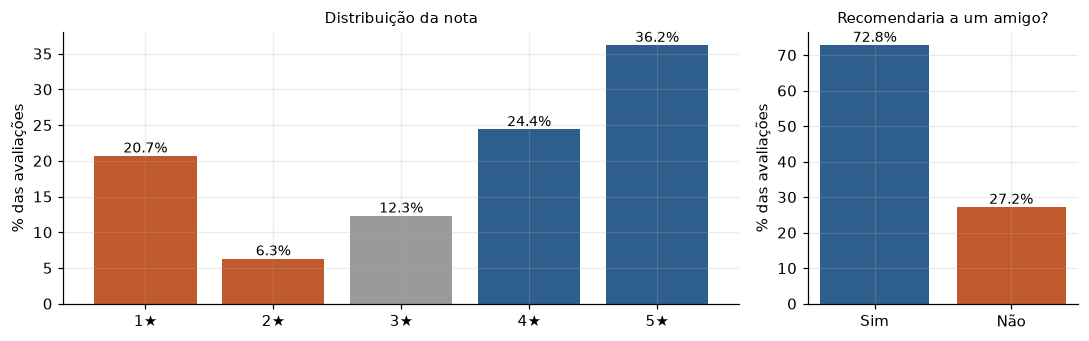

In [20]:
# ⟦célula 01.20⟧
fig, eixos = plt.subplots(1, 2, figsize=(10, 3.2), gridspec_kw={"width_ratios": [5, 2]})
b = eixos[0].bar([f"{i}★" for i in dist_nota.index], dist_nota.values, color=[LARANJA, LARANJA, CINZA, AZUL, AZUL])
eixos[0].bar_label(b, fmt="%.1f%%", fontsize=9); eixos[0].set_title("Distribuição da nota", fontsize=10)
b = eixos[1].bar(["Sim", "Não"], [dist_rec["Yes"], dist_rec["No"]], color=[AZUL, LARANJA])
eixos[1].bar_label(b, fmt="%.1f%%", fontsize=9); eixos[1].set_title("Recomendaria a um amigo?", fontsize=10)
for e in eixos: e.set_ylabel("% das avaliações")
fig.tight_layout(); print(salvar(fig, "01_distribuicao_rotulos")); plt.show()

figuras/01_categorias.png


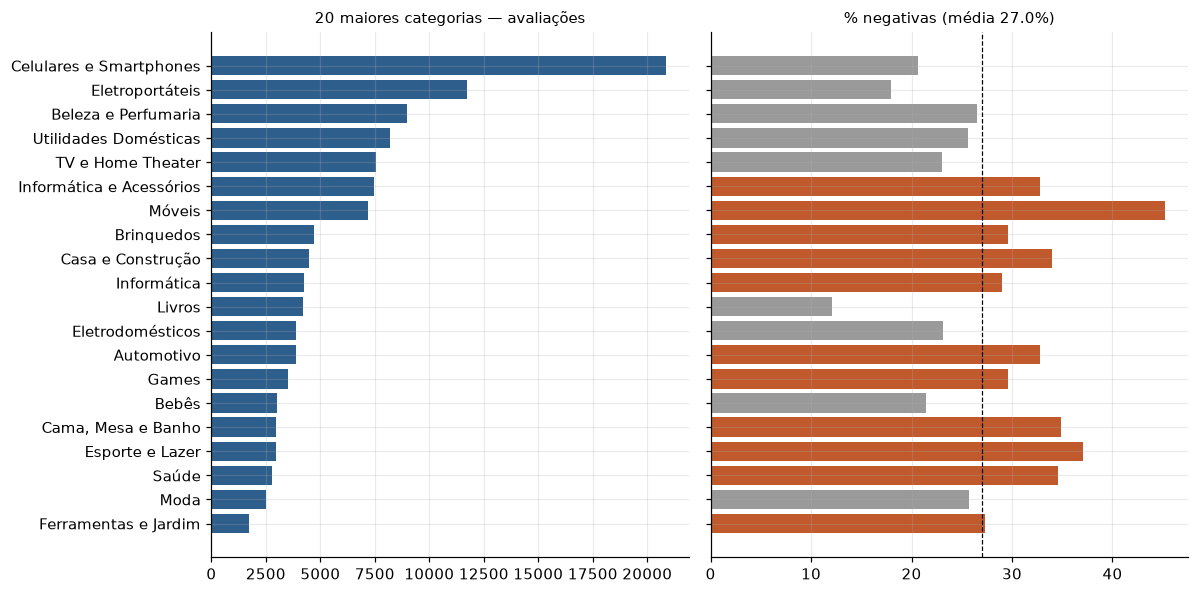

as 20 maiores categorias somam 88.3% da base


,avaliacoes,pct_negativas
site_category_lv1,,
Celulares e Smartphones,20859,20.6
Eletroportáteis,11745,18.0
Beleza e Perfumaria,8962,26.5
Utilidades Domésticas,8193,25.6
TV e Home Theater,7561,23.1
Informática e Acessórios,7469,32.8
Móveis,7166,45.3
Brinquedos,4712,29.6
Casa e Construção,4467,34.0


In [21]:
# ⟦célula 01.21⟧
# categorias: volume e % de avaliações negativas (1-2★) — o que o notebook 03 vai recortar
cat = df.groupby("site_category_lv1").agg(avaliacoes=("overall_rating", "size"),
                                          pct_negativas=("overall_rating", lambda s: (s <= 2).mean() * 100))
cat = cat.sort_values("avaliacoes", ascending=False)
top = cat.head(20).iloc[::-1]
media_neg = (nota <= 2).mean() * 100

fig, eixos = plt.subplots(1, 2, figsize=(11, 5.5), sharey=True)
eixos[0].barh(top.index, top["avaliacoes"], color=AZUL); eixos[0].set_title("20 maiores categorias — avaliações", fontsize=10)
eixos[1].barh(top.index, top["pct_negativas"], color=[LARANJA if v > media_neg else CINZA for v in top["pct_negativas"]])
eixos[1].axvline(media_neg, color="black", lw=0.8, ls="--"); eixos[1].set_title(f"% negativas (média {media_neg:.1f}%)", fontsize=10)
fig.tight_layout(); print(salvar(fig, "01_categorias")); plt.show()
print(f"as 20 maiores categorias somam {cat['avaliacoes'].head(20).sum()/len(df):.1%} da base")
cat.head(10).round(1)

---
## 6. O perfil do avaliador — só agregado

In [22]:
# ⟦célula 01.22⟧
ano = df["reviewer_birth_year"]
print(f"ano de nascimento: mínimo {ano.min():.0f} · máximo {ano.max():.0f} · faltando {ano.isna().sum():,}".replace(",", "."))
fora = ~ano.between(1920, 2005) & ano.notna()
print(f"anos fora de 1920-2005 (impossíveis para quem compra em 2018): {fora.sum():,}".replace(",", "."))
print(ano[fora].value_counts().sort_index().head(10).to_dict())
print("\ngênero (%):", df["reviewer_gender"].value_counts(normalize=True).mul(100).round(1).to_dict())
print("estados com mais avaliações (%):", df["reviewer_state"].value_counts(normalize=True).mul(100).round(1).head(6).to_dict())

ano de nascimento: mínimo 59 · máximo 2018 · faltando 5.984
anos fora de 1920-2005 (impossíveis para quem compra em 2018): 108
{59.0: 1, 61.0: 2, 66.0: 1, 71.0: 1, 78.0: 1, 83.0: 2, 85.0: 2, 88.0: 1, 1898.0: 1, 1899.0: 1}

gênero (%): {'M': 51.6, 'F': 48.4}
estados com mais avaliações (%): {'SP': 38.3, 'RJ': 13.7, 'MG': 12.7, 'PR': 5.3, 'RS': 5.2, 'BA': 3.7}


O ano de nascimento mínimo é **59** (sem o 19), e há **108** anos fora do intervalo 1920–2005, incluindo 1898 e
2018 (⟦célula 01.22⟧). São erros de digitação num campo livre. Como perfil não entra no modelo, a decisão é só para
a análise agregada do notebook 03: anos fora de 1920–2005 viram faltante. Gênero e estado são usados apenas em
tabelas por grupo, nunca associados a uma avaliação individual.

---
## 7. Decisão do rótulo

**Classe:** `overall_rating` em **duas classes**: **negativo = 1 e 2 estrelas**, **positivo = 4 e 5 estrelas**.
**As 3 estrelas saem do treino e do teste do classificador principal.**

**Por quê, com os números:**

* **88,5%** das 3★ recomendam o produto (⟦célula 01.10⟧): o "neutro" da nota não é neutro para quem escreveu.
  Um rótulo "neutro" que é, na verdade, "positivo com ressalva" ensina ao modelo uma fronteira que não existe no texto.
* Mesmo medida com cuidado, a classe neutra tem **recall 0,192** (⟦célula 01.16⟧): o modelo acerta uma em cada
  cinco. O notebook 02 refaz esse experimento com o pipeline completo e com pesos de classe, para confirmar que não
  é só falta de ajuste.
* A pergunta de negócio do projeto (*do que o cliente reclama*) precisa de um negativo limpo. Juntar 3★ ao negativo
  poluiria o negativo com quem recomenda; juntar ao positivo poluiria o positivo com as ressalvas.
* É a mesma decisão registrada no Lab 05, agora justificada pelos números desta base.

**O que o classificador NÃO recebe como entrada:** `recommend_to_a_friend` (acerta 96,5% sozinha) e o título
(classifica tão bem quanto o texto). O título só aparece no teste de vazamento do notebook 02.

**Limpeza antes do split:** remover avaliações sem texto (3.275), o texto de rótulo conflitante e as cópias de texto.

**Baseline:** a célula abaixo calcula a proporção das classes no conjunto que vai para o modelo e grava o chute
na maioria. **Ele aparece ao lado de toda acurácia dos notebooks seguintes.**

In [23]:
# ⟦célula 01.23⟧
base = df.copy()
base["linha_original"] = np.arange(len(base))
base["tem_texto"] = base["review_text"].notna() & (base["review_text"].str.strip() != "")
base["classe3"] = classe3(base["overall_rating"])
base["classe"] = np.where(base["overall_rating"] >= 4, "positivo",
                          np.where(base["overall_rating"] <= 2, "negativo", None))

# duplicatas: textos cujas cópias caem em classes opostas saem TODAS (rótulo ambíguo);
# das demais, fica a primeira ocorrência
textos_conflito = set(conflito.index)
base["texto_conflitante"] = base["review_text"].isin(textos_conflito)
base["duplicata"] = base["tem_texto"] & base["review_text"].duplicated(keep="first")
base["caixa_alta"] = CAIXA_ALTA.values

base["no_modelo"] = (base["tem_texto"] & base["classe"].notna()
                     & ~base["duplicata"] & ~base["texto_conflitante"])
base["no_modelo_3"] = base["tem_texto"] & ~base["duplicata"] & ~base["texto_conflitante"]

funil = pd.Series({
    "linhas na base": len(base),
    "com texto": int(base["tem_texto"].sum()),
    "com texto e nota ≠ 3": int((base["tem_texto"] & base["classe"].notna()).sum()),
    "… sem textos de rótulo conflitante": int((base["tem_texto"] & base["classe"].notna() & ~base["texto_conflitante"]).sum()),
    "… e sem duplicata (ENTRA NO MODELO)": int(base["no_modelo"].sum()),
}, name="avaliações")
display(funil.to_frame())

modelo = base[base["no_modelo"]]
prop = modelo["classe"].value_counts(normalize=True)
BASELINE = float(prop.max())
print(f"classes no conjunto do modelo: {prop.mul(100).round(1).to_dict()}")
print(f"BASELINE da classe majoritária ('{prop.idxmax()}'): {BASELINE:.3f}")

,avaliações
linhas na base,132373
com texto,129098
com texto e nota ≠ 3,113088
… sem textos de rótulo conflitante,113086
… e sem duplicata (ENTRA NO MODELO),110874


classes no conjunto do modelo: {'positivo': 70.6, 'negativo': 29.4}
BASELINE da classe majoritária ('positivo'): 0.706


In [24]:
# ⟦célula 01.24⟧
colunas_saida = ["linha_original", "submission_date", "product_id", "product_name", "site_category_lv1",
                 "site_category_lv2", "review_title", "review_text", "overall_rating", "recommend_to_a_friend",
                 "reviewer_state", "reviewer_gender", "reviewer_birth_year",          # só para análise agregada
                 "classe", "classe3", "tem_texto", "duplicata", "texto_conflitante", "caixa_alta",
                 "no_modelo", "no_modelo_3"]
base[colunas_saida].to_parquet("artefatos/base_auditada.parquet", index=False)

decisoes = {
    "fonte": URL, "semente": SEMENTE,
    "rotulo": "overall_rating binário: 1-2 negativo, 4-5 positivo, 3 fora",
    "colunas_proibidas_como_entrada": ["recommend_to_a_friend", "review_title (entra só no teste de vazamento)"],
    "n_modelo": int(base["no_modelo"].sum()),
    "proporcao_positivo": float(prop.get("positivo")),
    "baseline_maioria": BASELINE,
    "baseline_3_classes_com_texto": float(classes3.max() / 100),
    "pct_3_estrelas_recomendam": float(pct_3_recomenda),
    "definicao_caixa_alta": ">= 80% das letras em maiúscula",
}
Path("artefatos/decisoes.json").write_text(json.dumps(decisoes, ensure_ascii=False, indent=2))
print(json.dumps(decisoes, ensure_ascii=False, indent=2))

{
  "fonte": "https://raw.githubusercontent.com/americanas-tech/b2w-reviews01/main/B2W-Reviews01.csv",
  "semente": 42,
  "rotulo": "overall_rating binário: 1-2 negativo, 4-5 positivo, 3 fora",
  "colunas_proibidas_como_entrada": [
    "recommend_to_a_friend",
    "review_title (entra só no teste de vazamento)"
  ],
  "n_modelo": 110874,
  "proporcao_positivo": 0.705972545411909,
  "baseline_maioria": 0.705972545411909,
  "baseline_3_classes_com_texto": 0.614,
  "pct_3_estrelas_recomendam": 0.884707324547962,
  "definicao_caixa_alta": ">= 80% das letras em maiúscula"
}


---
## Resumo da auditoria

| Pergunta | Resposta curta | Célula |
|---|---|---|
| 1. Textos distintos | 126.724 de 129.098 com texto; 2.374 (1,8%) repetem outro. Há textos-modelo de 5★ em 57 produtos e uma campanha de 39 cópias contra um vendedor | 01.05, 01.06 |
| 2. Quem gerou o rótulo | o próprio cliente, no mesmo formulário. Nota e recomendação discordam em 2.863 + 1.213 avaliações, e 88,5% das 3★ recomendam | 01.09, 01.10 |
| 3. O que já entrega o rótulo | o **título** (regra de 15 palavras: 98,5% de acerto onde opina; modelo só no título ≈ modelo só no texto) e a **recomendação** (96,5%) | 01.14, 01.16, 01.10 |
| 4. Classes e baseline | 70,6% positivas × 29,4% negativas no conjunto do modelo (110.874 avaliações): **baseline 0,706** | 01.23 |

**Decisão do rótulo:** nota binária (1-2 × 4-5), 3★ fora, só o texto como entrada, sem duplicatas.